
██████████████████████████████████████████████████████████████████████
  ЛАБОРАТОРНАЯ РАБОТА №7: Критерий χ² для проверки нормальности
██████████████████████████████████████████████████████████████████████

  Таблица 1 — Нормальная выборка N(0,1), n=100
  n=100,  μ̂=-0.1038,  σ̂=0.9082,  k=10,  df=7
Интервал                   nᵢ      npᵢ    (nᵢ-npᵢ)²/npᵢ
----------------------------------------------------------------------
(−∞, -1.268)               11    10.00           0.1000
(-1.268, -0.868)            7    10.00           0.9000
(-0.868, -0.580)            8    10.00           0.4000
(-0.580, -0.334)           12    10.00           0.4000
(-0.334, -0.104)           13    10.00           0.9000
(-0.104, 0.126)             9    10.00           0.1000
(0.126, 0.372)             14    10.00           1.6000
(0.372, 0.660)              6    10.00           1.6000
(0.660, 1.060)             12    10.00           0.4000
(1.060, +∞)                 8    10.00           0.4000
-----------

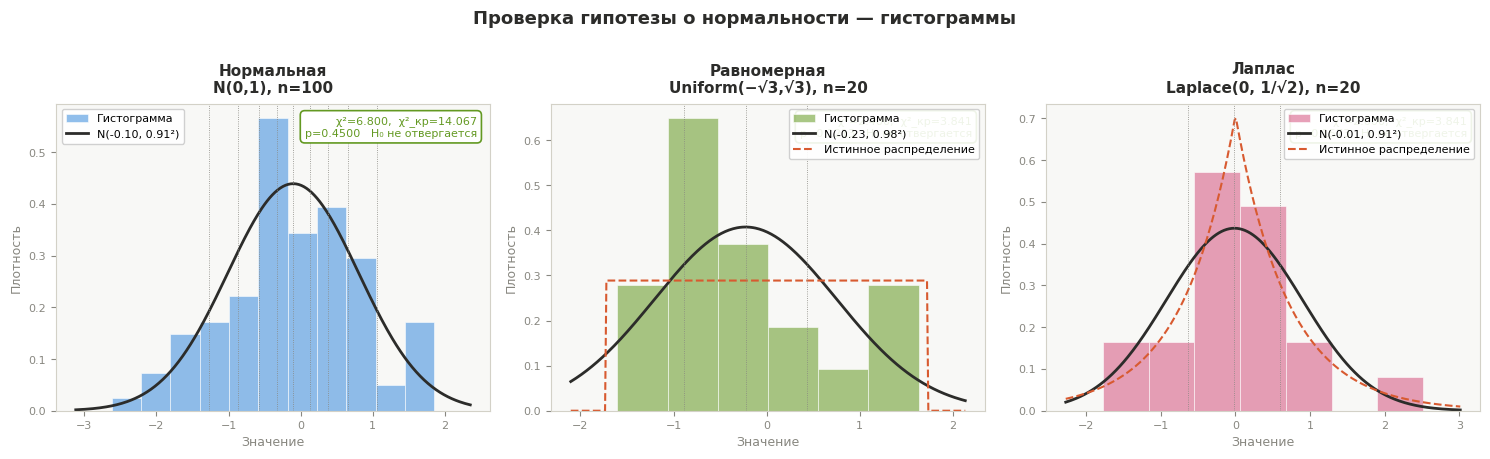

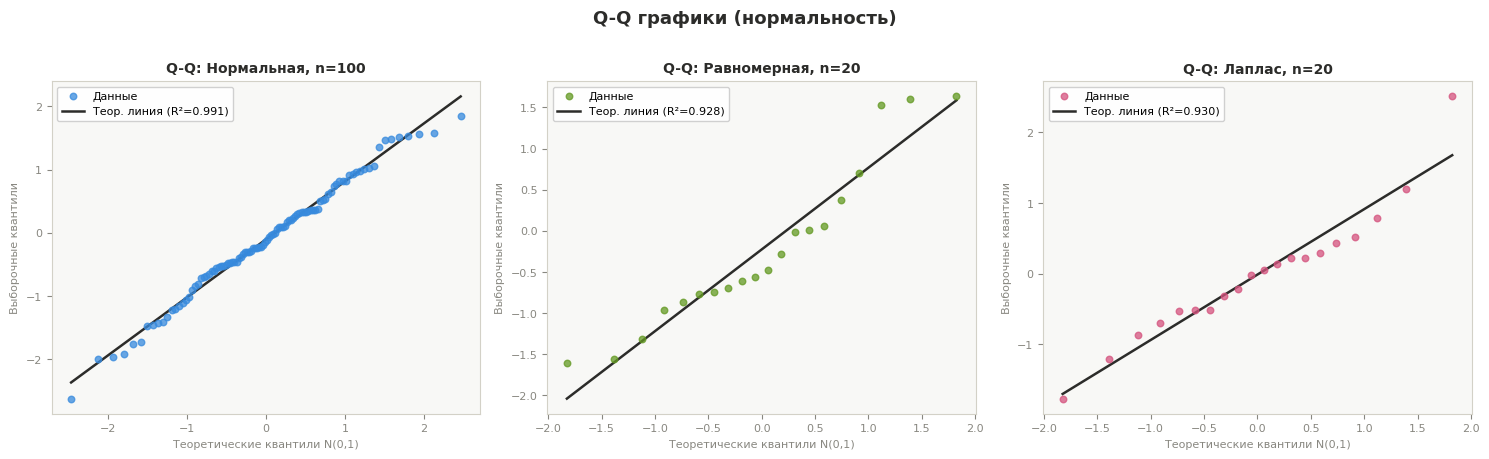

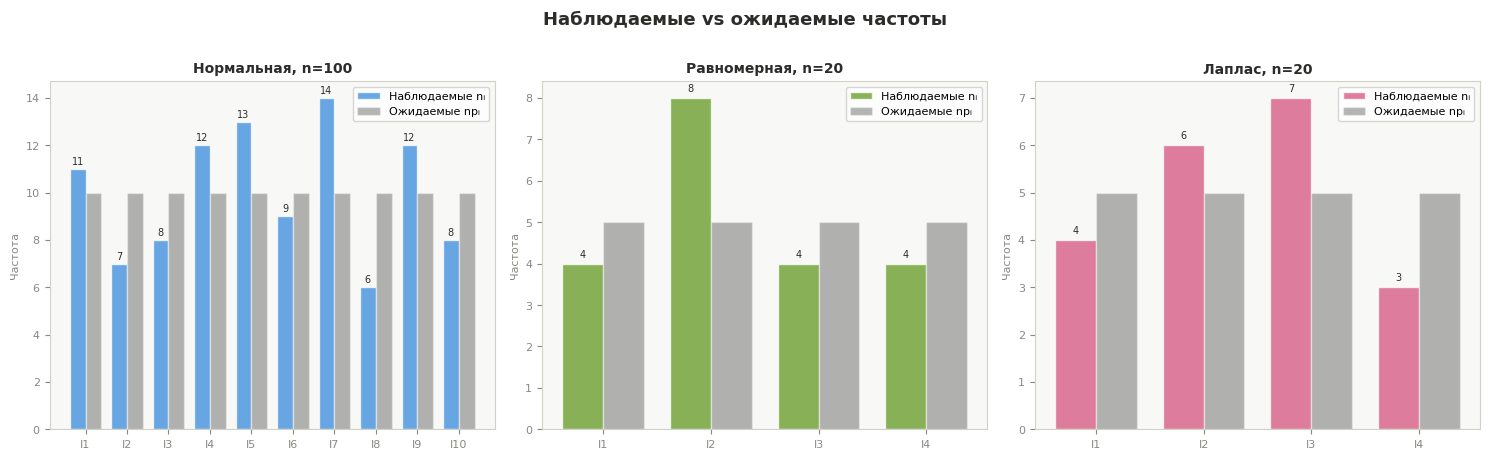


Готово.


In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

# ──────────────────────────────────────────────
#  Вспомогательные функции
# ──────────────────────────────────────────────

def chi2_test(sample, label=""):
    """
    Критерий χ² для проверки нормальности.
    Параметры μ и σ оцениваются по ММП.
    Интервалы — равновероятные (квантили нормального), npᵢ ≥ 5.
    """
    n = len(sample)
    mu_hat  = np.mean(sample)
    sig_hat = np.std(sample, ddof=1)

    # число интервалов: npᵢ >= 5  →  k <= n/5
    k = min(int(np.sqrt(n)), n // 5)
    k = max(k, 4)

    probs   = np.linspace(0, 1, k + 1)
    borders = stats.norm.ppf(probs, loc=mu_hat, scale=sig_hat)
    borders[0], borders[-1] = -np.inf, np.inf

    observed = np.array([
        np.sum((sample >= borders[i]) & (sample < borders[i + 1]))
        for i in range(k)
    ], dtype=float)
    expected = np.full(k, n / k, dtype=float)

    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    df        = k - 1 - 2          # −2 за оценённые параметры
    df        = max(df, 1)
    p_val     = 1 - stats.chi2.cdf(chi2_stat, df)
    chi2_crit = stats.chi2.ppf(0.95, df)
    reject    = chi2_stat > chi2_crit

    # вывод таблицы
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"  n={n},  μ̂={mu_hat:.4f},  σ̂={sig_hat:.4f},  k={k},  df={df}")
    print(f"{'='*70}")
    header = f"{'Интервал':<22} {'nᵢ':>6} {'npᵢ':>8} {'(nᵢ-npᵢ)²/npᵢ':>16}"
    print(header)
    print('-' * 70)
    for i in range(k):
        lo = "−∞"       if np.isinf(borders[i])   else f"{borders[i]:.3f}"
        hi = "+∞"       if np.isinf(borders[i+1]) else f"{borders[i+1]:.3f}"
        interval = f"({lo}, {hi})"
        contrib  = (observed[i] - expected[i]) ** 2 / expected[i]
        print(f"{interval:<22} {int(observed[i]):>6} {expected[i]:>8.2f} {contrib:>16.4f}")
    print('-' * 70)
    print(f"{'Итого':<22} {int(observed.sum()):>6} {expected.sum():>8.2f} {chi2_stat:>16.4f}")
    print()
    print(f"  χ²_набл = {chi2_stat:.4f}")
    print(f"  χ²_кр  = {chi2_crit:.4f}  (α=0.05, df={df})")
    print(f"  p-value = {p_val:.4f}")
    verdict = "ОТВЕРГАЕТСЯ ✗" if reject else "не отвергается ✓"
    print(f"  H₀ {verdict}")

    return dict(mu=mu_hat, sig=sig_hat, k=k, chi2=chi2_stat,
                chi2_crit=chi2_crit, pval=p_val, reject=reject,
                borders=borders, observed=observed, expected=expected)




normal_sample  = np.random.normal(0, 1, 100)
uniform_sample = np.random.uniform(-np.sqrt(3), np.sqrt(3), 20)
laplace_sample = np.random.laplace(0, 1 / np.sqrt(2), 20)

print("\n" + "█"*70)
print("  ЛАБОРАТОРНАЯ РАБОТА №7: Критерий χ² для проверки нормальности")
print("█"*70)

r1 = chi2_test(normal_sample,  "Таблица 1 — Нормальная выборка N(0,1), n=100")
r2 = chi2_test(uniform_sample, "Таблица 2 — Равномерная выборка Uniform(−√3, √3), n=20")
r3 = chi2_test(laplace_sample, "Таблица 3 — Выборка Лапласа, n=20")



BLUE   = "#378ADD"
RED    = "#D85A30"
GREEN  = "#639922"
GRAY   = "#888780"
BG     = "#F8F8F6"
DARK   = "#2C2C2A"

def plot_panel(ax, sample, result, title, dist_color, dist_rv=None):
    """
    Гистограмма + подогнанная нормальная кривая + Q-Q plot на одном Axes.
    """
    n   = len(sample)
    mu  = result["mu"]
    sig = result["sig"]

    counts, bin_edges, patches = ax.hist(
        sample, bins="auto", density=True,
        color=dist_color, alpha=0.55, edgecolor="white", linewidth=0.7,
        label="Гистограмма"
    )


    x = np.linspace(sample.min() - 0.5, sample.max() + 0.5, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sig),
            color=DARK, linewidth=2, label=f"N({mu:.2f}, {sig:.2f}²)")

    # --- истинное распределение (если задано) ---
    if dist_rv is not None:
        ax.plot(x, dist_rv.pdf(x), color=RED, linewidth=1.5,
                linestyle="--", label="Истинное распределение")

    # вертикальные линии границ интервалов
    for b in result["borders"][1:-1]:
        ax.axvline(b, color=GRAY, linewidth=0.6, linestyle=":")

    # аннотация результата
    verdict_txt = "H₀ отвергается" if result["reject"] else "H₀ не отвергается"
    color_v     = RED if result["reject"] else GREEN
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8, color=DARK)
    ax.set_xlabel("Значение", fontsize=9, color=GRAY)
    ax.set_ylabel("Плотность", fontsize=9, color=GRAY)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.set_facecolor(BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#D3D1C7")

    # подпись χ²
    info = (f"χ²={result['chi2']:.3f},  "
            f"χ²_кр={result['chi2_crit']:.3f}\n"
            f"p={result['pval']:.4f}   {verdict_txt}")
    ax.text(0.97, 0.96, info, transform=ax.transAxes,
            fontsize=8, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=color_v, linewidth=1.2),
            color=color_v)


def plot_qq(ax, sample, result, title, color):
    """Q-Q plot относительно подогнанного нормального распределения."""
    mu, sig = result["mu"], result["sig"]
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist="norm", fit=True)
    ax.scatter(osm, osr, s=22, color=color, alpha=0.75, zorder=3, label="Данные")
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept,
            color=DARK, linewidth=1.8, label=f"Теор. линия (R²={r**2:.3f})")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6, color=DARK)
    ax.set_xlabel("Теоретические квантили N(0,1)", fontsize=8, color=GRAY)
    ax.set_ylabel("Выборочные квантили", fontsize=8, color=GRAY)
    ax.set_facecolor(BG)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.tick_params(colors=GRAY, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#D3D1C7")


# ──────────────────────────────────────────────
#  Фигура 1: гистограммы + кривые
# ──────────────────────────────────────────────

fig1, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig1.patch.set_facecolor("white")
fig1.suptitle("Проверка гипотезы о нормальности — гистограммы",
              fontsize=13, fontweight="bold", color=DARK, y=1.01)

plot_panel(axes[0], normal_sample,  r1,
           "Нормальная\nN(0,1), n=100", BLUE)

plot_panel(axes[1], uniform_sample, r2,
           "Равномерная\nUniform(−√3,√3), n=20", GREEN,
           dist_rv=stats.uniform(loc=-np.sqrt(3), scale=2*np.sqrt(3)))

plot_panel(axes[2], laplace_sample, r3,
           "Лаплас\nLaplace(0, 1/√2), n=20", "#D4537E",
           dist_rv=stats.laplace(loc=0, scale=1/np.sqrt(2)))

fig1.tight_layout()
fig1.savefig("C:\\vscode_proj\\python\\PROGA\\matstat\\math-statistic\\lab7\\chi2_histograms.png",
             dpi=150, bbox_inches="tight", facecolor="white")
print("\n[✓] chi2_histograms.png сохранён")


# ──────────────────────────────────────────────
#  Фигура 2: Q-Q plots
# ──────────────────────────────────────────────

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.5))
fig2.patch.set_facecolor("white")
fig2.suptitle("Q-Q графики (нормальность)",
              fontsize=13, fontweight="bold", color=DARK, y=1.01)

plot_qq(axes2[0], normal_sample,  r1,
        "Q-Q: Нормальная, n=100", BLUE)
plot_qq(axes2[1], uniform_sample, r2,
        "Q-Q: Равномерная, n=20", GREEN)
plot_qq(axes2[2], laplace_sample, r3,
        "Q-Q: Лаплас, n=20", "#D4537E")

fig2.tight_layout()
fig2.savefig("C:\\vscode_proj\\python\\PROGA\\matstat\\math-statistic\\lab7\\chi2_qq.png",
             dpi=150, bbox_inches="tight", facecolor="white")
print("[✓] chi2_qq.png сохранён")


# ──────────────────────────────────────────────
#  Фигура 3: наблюдаемые vs ожидаемые частоты
# ──────────────────────────────────────────────

def plot_freq(ax, result, title, color):
    k      = result["k"]
    obs    = result["observed"]
    exp    = result["expected"]
    labels = [f"I{i+1}" for i in range(k)]
    x      = np.arange(k)
    w      = 0.38
    bars_o = ax.bar(x - w/2, obs, width=w, color=color,   alpha=0.75, label="Наблюдаемые nᵢ", edgecolor="white")
    bars_e = ax.bar(x + w/2, exp, width=w, color=DARK,    alpha=0.35, label="Ожидаемые npᵢ",  edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold", color=DARK)
    ax.set_ylabel("Частота", fontsize=8, color=GRAY)
    ax.legend(fontsize=8)
    ax.set_facecolor(BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#D3D1C7")
    # значения над столбцами
    for bar in bars_o:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=7, color=DARK)

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4.5))
fig3.patch.set_facecolor("white")
fig3.suptitle("Наблюдаемые vs ожидаемые частоты",
              fontsize=13, fontweight="bold", color=DARK, y=1.01)

plot_freq(axes3[0], r1, "Нормальная, n=100",        BLUE)
plot_freq(axes3[1], r2, "Равномерная, n=20",         GREEN)
plot_freq(axes3[2], r3, "Лаплас, n=20",              "#D4537E")

fig3.tight_layout()
fig3.savefig("C:\\vscode_proj\\python\\PROGA\\matstat\\math-statistic\\lab7\\chi3.png",
             dpi=150, bbox_inches="tight", facecolor="white")
print("[✓] chi2_freq.png сохранён")

plt.show()
print("\nГотово.")